In [1]:
import numpy as np
from math import sqrt, exp
from numba import jit, njit
import numba
numba.config.DEBUG = False

import sys
import logging
import pytest
import pandas as pd
from scipy.stats import norm
from dataclasses import dataclass
from datetime import datetime, date, timedelta
from pandas import Series, date_range
from typing import Iterable
import matplotlib.pyplot as plt
import copy
from datetime import timedelta, date
from dateutil import parser

import requests
from scipy.optimize import minimize
import matplotlib.dates as mdates

STORAGE /SWING MODEL:

In [2]:
# STORAGE MODEL

"""
    Clewlow–Strickland one-factor trinomial tree for log-price with mean reversion.
    https://ssrn.com/abstract=160608
    Parameters
    ----------
    price_curve : array-like, shape (n_t,)
        Forward price curve.
    n_t : int
        Number of time steps (days).
    n_p : int
        Half-width of price states (states = 2*n_p + 1).
    vol_curve : array-like, shape (n_t,)
        Volatility curve.
    mr_curve : array-like, shape (n_t,)
        Mean reversion curve.

    Returns
    -------
    fwd : ndarray, shape (n_t,)
    x : ndarray, shape (n_t, 2*n_p+1)
        Log-price grid.
    q : ndarray, shape (n_t, 2*n_p+1)
        State probabilities.
    p_u, p_m, p_d : ndarray, shape (n_t, 2*n_p+1)
        Transition probabilities.
"""

import numpy as np
from numba import njit
from math import sqrt, exp


def build_tree(price_curve, n_t, n_p, vol_curve, mr_curve):
    dt = 1.0 / 365.0
    dx = vol_curve[0] * sqrt(3.0 * dt)

    fwd = np.asarray(price_curve, dtype=np.float64)
    n_states = 2 * n_p + 1

    x   = np.zeros((n_t, n_states), dtype=np.float64)
    kpar= np.zeros((n_t, n_states), dtype=np.int64)
    p_u = np.zeros((n_t, n_states), dtype=np.float64)
    p_d = np.zeros((n_t, n_states), dtype=np.float64)
    p_m = np.zeros((n_t, n_states), dtype=np.float64)
    q   = np.zeros((n_t, n_states), dtype=np.float64)

    # grid
    for i in range(n_t):
        j_min, j_max = max(n_p - i, 0), min(n_p + i, 2*n_p)
        for j in range(j_min, j_max + 1):
            x[i, j] = (j - n_p) * dx

    # transitions
    for i in range(n_t):
        vol, mr = vol_curve[i], mr_curve[i]
        j_min, j_max = max(n_p - i, 0), min(n_p + i, 2*n_p)
        for j in range(j_min, j_max + 1):
            if n_p == 0:
                p_m[i, j] = 1.0
                continue
            kpar[i, j] = int(-mr * dt * x[i, j] + 0.5)
            a = (vol**2 * dt + (dt * mr * x[i, j])**2) / dx**2 + kpar[i, j]**2
            b = -mr * x[i, j] * dt / dx * (1 - 2*kpar[i, j]) - kpar[i, j]
            c =  mr * x[i, j] * dt / dx * (1 + 2*kpar[i, j]) + kpar[i, j]
            if j == 0:
                p_u[i, j] = 0.5 * (b - c)
                p_m[i, j] = 1.0 - p_u[i, j]
            elif j == 2*n_p:
                p_d[i, j] = 0.5 * (c - b)
                p_m[i, j] = 1.0 - p_d[i, j]
            else:
                p_u[i, j] = 0.5 * (a + b)
                p_d[i, j] = 0.5 * (a + c)
                p_m[i, j] = 1.0 - p_u[i, j] - p_d[i, j]

    # probabilities q
    q[0, n_p] = 1.0
    for i in range(1, n_t):
        for j in range(n_states):
            val = 0.0
            if j > 0:
                val += p_u[i-1, j-1] * q[i-1, j-1]
            if j < n_states - 1:
                val += p_d[i-1, j+1] * q[i-1, j+1]
            val += p_m[i-1, j] * q[i-1, j]
            q[i, j] = val

    # distortion
    offset = np.zeros(n_t)
    

    for i in range(n_t):
        expected = 0.0
        for j in range(n_states):
            expected += q[i, j] * exp(x[i, j])
        offset[i] = np.log(fwd[i] / expected)
        for j in range(n_states):
            x[i, j] += offset[i]

    return fwd, x, q, p_u, p_m, p_d
"""
The run_model function does stochastic forward looking optimisation to determine an expected
optimised value by building on the price dynamics captured in the trinomial tree built by build_tree.
It uses dynamic programming: step back in time and constan_tly build on the future optimised value.
"""


@njit(cache=True, fastmath=True)
def run_model(n_t, n_p, n_op, v_step,
              x, p_u, p_m, p_d,
              d_curve, i_curve, w_curve,
              i_cost, w_cost,
              t_p_curve, i_ratch, w_ratch,
              mintunnel, max_tunnel):
    """
    Backward induction over (time, price-state, volume-state).
    Returns value array v and strategy array strat.
    """
    NEG_BIG = -1.0e19
    n_states = 2 * n_p + 1

    v = np.zeros((n_t, n_states, n_op), dtype=np.float64)
    strat = np.zeros((n_t, n_states, n_op), dtype=np.float64)

    # Terminal payoff
    for k in range(n_states):
        for l in range(n_op):
            v[n_t - 1, k, l] = t_p_curve[l]

    # Backward induction
    for i in range(n_t - 2, -1, -1):
        z = i
        k_min = max(n_p - z, 0)
        k_max = min(n_p + z, 2 * n_p)

        for k in range(k_min, k_max + 1):
            for l in range(n_op):
                # Action magnitudes
                wdr_step = w_curve[i] * w_ratch[l]
                inj_step = i_curve[i] * i_ratch[l]

                # Withdrawal
                wdr_units = int(min(wdr_step, l))
                if wdr_units > 0:
                    cont_wdr = 0.0
                    if k > 0:
                        cont_wdr += p_d[z, k] * v[z + 1, k - 1, l - wdr_units]
                    if k < n_states - 1:
                        cont_wdr += p_u[z, k] * v[z + 1, k + 1, l - wdr_units]
                    cont_wdr += p_m[z, k] * v[z + 1, k, l - wdr_units]
                    wdr_val = cont_wdr + d_curve[i] * wdr_units * v_step * (exp(x[z, k]) - w_cost[i])
                else:
                    wdr_val = NEG_BIG

                # Hold
                cont_hold = 0.0
                if k > 0:
                    cont_hold += p_d[z, k] * v[z + 1, k - 1, l]
                if k < n_states - 1:
                    cont_hold += p_u[z, k] * v[z + 1, k + 1, l]
                cont_hold += p_m[z, k] * v[z + 1, k, l]

                # Injection
                inj_units = int(min(inj_step, (n_op - 1) - l))
                if inj_units > 0:
                    cont_inj = 0.0
                    if k > 0:
                        cont_inj += p_d[z, k] * v[z + 1, k - 1, l + inj_units]
                    if k < n_states - 1:
                        cont_inj += p_u[z, k] * v[z + 1, k + 1, l + inj_units]
                    cont_inj += p_m[z, k] * v[z + 1, k, l + inj_units]
                    inj_val = cont_inj + d_curve[i] * inj_units * v_step * (-exp(x[z, k]) - i_cost[i])
                else:
                    inj_val = NEG_BIG

                # Choose best
                best_val = cont_hold
                best_act = 0.0
                if wdr_val > best_val:
                    best_val = wdr_val
                    best_act = -1.0
                if inj_val > best_val:
                    best_val = inj_val
                    best_act = 1.0

                # Tie-break toward hold
                if (best_val - cont_hold) < 1e-6:
                    best_val = cont_hold
                    best_act = 0.0

                # Tunnel penalty
                breach_low = mintunnel[i] - l
                breach_high = l - max_tunnel[i]
                penalty = 0.0
                if breach_low > 0:
                    penalty += 1000.0 * v_step * breach_low
                if breach_high > 0:
                    penalty += 1000.0 * v_step * breach_high

                v[z, k, l] = best_val - penalty
                strat[z, k, l] = best_act

    return v, strat


def valuation(n_p, v, q, n_op_start):
    """
    Compute the expected valuation at time 0 for a given starting volume state.

    Parameters
    ----------
    n_p : int
        Half-width of price states (states = 2*n_p+1).
    v : ndarray
        Value array of shape (n_t, 2*n_p+1, n_op).
    q : ndarray
        State probability array of shape (n_t, 2*n_p+1).
    n_op_start : int
        Starting volume state index.

    Returns
    -------
    float
        Expected valuation at time 0.
    """
    n_states = 2 * n_p + 1
    # slice of values at time 0 for given volume
    v0 = v[0, :n_states, n_op_start]
    q0 = q[0, :n_states]
    return float(np.dot(v0, q0))

@njit(cache=True, fastmath=True)
def probabilities(n_t, n_p, n_op,
                  q, strat, p_u, p_m, p_d,
                  i_curve, w_curve, i_ratch, w_ratch,
                  n_op_start, mintunnel, max_tunnel):
    """
    Forward propagation of probability mass over (time, price-state, volume-state),
    given a fixed strategy strat[i,j,k] ∈ {-1,0,+1}.
    """
    n_states = 2 * n_p + 1
    prob = np.zeros((n_t, n_states, n_op), dtype=np.float64)

    # Initialise at time 0
    k0 = n_op_start
    if k0 < mintunnel[0]:
        k0 = mintunnel[0]
    elif k0 > max_tunnel[0]:
        k0 = max_tunnel[0]
    for j in range(n_states):
        prob[0, j, k0] = q[0, j]

    # Forward propagation
    for i in range(n_t - 1):
        j_min = max(n_p - i, 0)
        j_max = min(n_p + i, 2 * n_p)

        pu = p_u[i]
        pm = p_m[i]
        pd = p_d[i]

        for j in range(j_min, j_max + 1):
            for k in range(n_op):
                mass = prob[i, j, k]
                if mass == 0.0:
                    continue

                # Action step size
                dki = strat[i, j, k]
                dk = 0
                if dki == -1.0:
                    wdr_units = int(min(w_curve[i] * w_ratch[k], k))
                    if wdr_units > 0:
                        dk = -wdr_units
                elif dki == 1.0:
                    inj_units = int(min(i_curve[i] * i_ratch[k], (n_op - 1) - k))
                    if inj_units > 0:
                        dk = inj_units

                k_next = k + dk
                if k_next < mintunnel[i + 1]:
                    k_next = mintunnel[i + 1]
                elif k_next > max_tunnel[i + 1]:
                    k_next = max_tunnel[i + 1]

                # Vectorised price transitions: j→j-1, j, j+1
                if j > 0:
                    prob[i + 1, j - 1, k_next] += pd[j] * mass
                prob[i + 1, j, k_next] += pm[j] * mass
                if j < n_states - 1:
                    prob[i + 1, j + 1, k_next] += pu[j] * mass

    return prob

@njit(cache=True, fastmath=True)
def get_exercise(i, n_p, n_op,
                 prob, strat,
                 i_ratch, w_ratch,
                 v_step, w_curve, i_curve):
    """
    Compute expected net exercise (volume change) at time i.
    Withdrawals are negative, injections positive, hold is zero.
    Returns: -expected exercise (rounded outside Numba if needed).
    """
    n_states = 2 * n_p + 1
    total = 0.0

    for j in range(n_states):
        for k in range(n_op):
            mass = prob[i, j, k]
            if mass == 0.0:
                continue

            a = strat[i, j, k]

            # Withdrawal units
            wdr_units = int(min(w_curve[i] * w_ratch[k], k))
            # Injection units
            inj_units = int(min(i_curve[i] * i_ratch[k], (n_op - 1) - k))

            # Action units
            if a == -1.0 and wdr_units > 0:
                action_units = -float(wdr_units) * v_step
            elif a == 1.0 and inj_units > 0:
                action_units = float(inj_units) * v_step
            else:
                action_units = 0.0

            total += action_units * mass

    return -total

@njit(cache=True, fastmath=True)
def get_delta(i, n_p, n_op,
              prob, strat,
              i_ratch, w_ratch,
              v_step, w_curve, i_curve,
              x, fwd):
    """
    Compute expected delta (sensitivity to price) at time i.
    Withdrawals are negative, injections positive, hold is zero.
    Returns: -expected delta / fwd[i].
    """
    n_states = 2 * n_p + 1
    total = 0.0

    for j in range(n_states):
        price = exp(x[i, j])
        for k in range(n_op):
            mass = prob[i, j, k]
            if mass == 0.0:
                continue

            a = strat[i, j, k]

            # Withdrawal units
            wdr_units = int(min(w_curve[i] * w_ratch[k], k))
            # Injection units
            inj_units = int(min(i_curve[i] * i_ratch[k], (n_op - 1) - k))

            # Action units
            if a == -1.0 and wdr_units > 0:
                action_units = -float(wdr_units) * v_step
            elif a == 1.0 and inj_units > 0:
                action_units = float(inj_units) * v_step
            else:
                action_units = 0.0

            total += action_units * mass * price

    return -(total / fwd[i])

In [3]:
# Storage facility specs
valDate = date(2025, 12, 9)
currentDate = valDate
storageStart = date(2026, 4, 1)
storageEnd = date(2027, 3, 30) 
backStop = date(2027, 4, 30) 
Dt = (storageStart - currentDate).days 
n_t = (backStop - currentDate).days 
date_span = pd.date_range(currentDate, backStop, freq='D')
months = pd.DataFrame(index=date_span).resample('ME').sum()
active_span = pd.date_range(currentDate, storageEnd, freq='D')
active = len(active_span)
n_op = 90 + 1 # number of volume states in storage + 1
v_step =  10000 # volume per state in MWh
i_curve = np.array([1. for x in date_span])  # injection rate: 1 volumes states / day
i_curve[active:] = 0 # no inject allowed after to contract end
w_curve = np.array([1. for x in date_span]) # withdrawal rate: 1 volumes states / day
w_curve[active:] = 0 # no withdrawal allowed after to contract end
i_cost = np.array([0. for x in date_span]) # EU/MWh injection cost
w_cost = np.array([0. for x in date_span]) # EU/MWh withdrawal cost
t_p_curve = np.array([-1e9 for x in range(n_op+2)]) 
t_p_curve[0] = 0. 
i_curve[0:Dt] = 0. # no inject allowed prior to contract start
w_curve[0:Dt] = 0. # no withdrawal allowed prior to contract start
mintunnel = np.array([0 for x in date_span])     # min inventory level
i_ratch = np.array([1. for x in range(n_op)])    # injection ratchet
w_ratch = np.array([1. for x in range(n_op)])    # withdrawal ratchet
max_tunnel = np.array([n_op for x in date_span]) # maximum inventory level
n_op_start = 0 # start full for swing, start empty for storage
n_p = 0 # number of price states = 2 * n_p + 1. n_p = 0 yields intrinsic

In [4]:
# Market parameters
sVol = [0.6 for x in date_span] # Spot volatlty curve 0.9 (Engie old) 0.6 (Romilly and current) 
sMR = [ 0.65 for x in date_span]  # Spot Mean Reversion curve 0.55 (Engie) 1.0 (Romilly) 0.65 (current)
d_curve = np.array([1. for x in date_span]) # discount factor curve

In [6]:
# Read Forward Curve
def get_value_for_date(date, df):
    for _, row in df.iterrows():
        if row['contractStart'] <= date <= row['contractEnd']:
            return row['value']
    return None
curve = pd.DataFrame(pd.read_csv("curve.csv"))
curve['contractStart'] = pd.to_datetime(curve['contractStart'], format='%d-%b-%y')
curve['contractEnd'] = pd.to_datetime(curve['contractEnd'], format='%d-%b-%y')
price_curve_0 = pd.Series([get_value_for_date(date, curve) for date in date_span], index=date_span).to_frame(name='value')

In [ ]:
# intrinsic
n_p = 0 

# Build Price Tree:
fwd, x, q, p_u, p_m, p_d = build_tree(price_curve_0, n_t, n_p, sVol, sMR)

# Run model
v, strat = run_model(n_t, n_p, n_op, v_step, x, p_u, p_m, p_d, d_curve, i_curve, w_curve, i_cost, w_cost, t_p_curve, i_ratch, w_ratch , mintunnel, max_tunnel)
prob = probabilities(n_t, n_p, n_op, q, strat, p_u, p_m, p_d, i_curve, w_curve, i_ratch, w_ratch, n_op_start, mintunnel, max_tunnel)

delta_intr = []
exp_ex_intr = []
for i in range(n_t):
    exp_ex_intr.append(get_exercise(i, n_p, n_op, prob, strat, i_ratch, w_ratch, v_step, w_curve, i_curve))#, x, fwd))
    delta_intr.append(get_delta(i, n_p, n_op, prob, strat, i_ratch, w_ratch, v_step, w_curve, i_curve, x, fwd))
delta_intr.append(0)
exp_ex_intr.append(0)

Intrinsic = v[0,0,n_op_start]
print("Intrinsic = {:,.0f}".format(Intrinsic))

# intrinsic + extrinsic
n_p = 50 # number of price states = 2 * n_p + 1

# Build Price Tree:
fwd, x, q, p_u, p_m, p_d = build_tree(price_curve_0, n_t, n_p, sVol, sMR)

# Compute intrinsic + extrinsic
v, strat = run_model(n_t, n_p, n_op, v_step, x, p_u, p_m, p_d, d_curve, i_curve, w_curve, i_cost, w_cost, t_p_curve, i_ratch, w_ratch , mintunnel, max_tunnel)
prob = probabilities(n_t, n_p, n_op, q, strat, p_u, p_m, p_d, i_curve, w_curve, i_ratch, w_ratch, n_op_start, mintunnel, max_tunnel)
delta = []
exp_ex = []
for i in range(n_t):
    exp_ex.append(get_exercise(i, n_p, n_op, prob, strat, i_ratch, w_ratch, v_step, w_curve, i_curve))#, x, fwd))
    delta.append(get_delta(i, n_p, n_op, prob, strat, i_ratch, w_ratch, v_step, w_curve, i_curve, x, fwd))
delta.append(0)
exp_ex.append(0)

FullValueEuro = v[0,n_p,n_op_start]
print("Intrinsic + Extrinsic Value = {:,.0f}".format(FullValueEuro))

C:\Users\user\AppData\Local\Temp\ipykernel_17724\1925085432.py:98: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  offset[i] = np.log(fwd[i] / expected)


Intrinsic = 1,339,200
Intrinsic + Extrinsic Value = 2,576,210


In [ ]:
delta_intr = [float(a) for a in delta_intr]
delta = [float(a) for a in delta]
exp_ex= [float(a) for a in exp_ex]


C:\Users\user\AppData\Local\Temp\ipykernel_17724\2382513800.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  delta_intr = [float(a) for a in delta_intr]
C:\Users\user\AppData\Local\Temp\ipykernel_17724\2382513800.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  delta = [float(a) for a in delta]


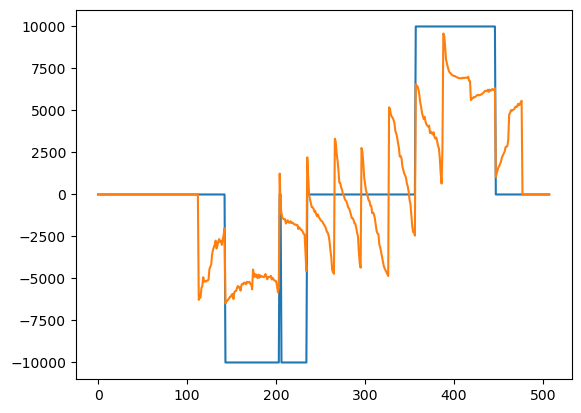

In [ ]:
plt.plot(delta_intr)
plt.plot(delta)

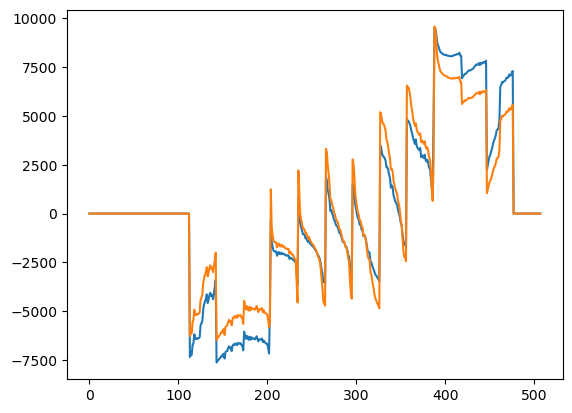

In [ ]:
plt.plot(exp_ex)
plt.plot(delta)